In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pro_solvers import solve_heat, solve_heat2d
from mpl_toolkits.mplot3d import Axes3D
#from pde_solvers import fdm
plt.rcParams["figure.figsize"] = (5, 3)  # width x height in inches
from matplotlib.animation import FuncAnimation
#from manim import *
#from manim.utils.ipython_magic import ManimMagic
#get_ipython().register_magics(ManimMagic)

#%load_ext manim

In [2]:
# PDE: u_t = alpha u_xx
alpha = 2.0
L = 1.0
dx = 0.01
dt = 0.0001
t_end = 0.05  # Try varying this

# Initial condition: sin(3 pi x)
#u0 = lambda x: np.sin(3 * np.pi * x) + 1
#u0 = lambda x: x**2
#u0 = lambda x : np.where(np.sin(100*x) > 0.0, 1.0, 0.0)
#u0 = lambda x: np.where(np.abs(x) < .1, 100.0, 0.0)

N = 100
C = np.random.rand(N)
def u0(x):
    u = 0
    k = 0
    while k < N:
        u += C[k]*np.sin((k+1) * np.pi * x) / (k+1)
        k += 1
    return u

#u0 = lambda x: 10*np.exp(-100*(x-.5)**2)
# Exact solution
#def u_exact(x, t):
#    return np.exp(-18 * np.pi**2 * t) * np.sin(3 * np.pi * x)

def u_exact(x, t):
    u = np.zeros_like(x)  # initialize with same shape as x
    k = 0
    while k < N:
        term = C[k] * np.exp(-(k+1)**2 * np.pi**2 * t * alpha) * np.sin((k+1) * np.pi * x) / (k+1)
        u += term
        k += 1
    return u



T, U = solve_heat(u0, alpha, dx, t_end, L, dt = dt, leftval = 0, rightval = 0)

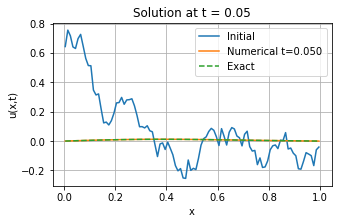

In [3]:
x = np.linspace(dx/2, L - dx/2, int(L/dx))  # FiPy's cell centers

plt.plot(x, U[0], label='Initial')
plt.plot(x, U[-1], label=f'Numerical t={t_end:.3f}')
plt.plot(x, u_exact(x, t_end), '--', label='Exact')


plt.title(f"Solution at t = {t_end}")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.legend()
plt.grid(True)
plt.show()

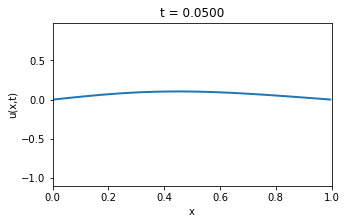

In [5]:
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots()
line, = ax.plot([], [], lw=2)
ax.set_xlim(0, L)
ax.set_ylim(-1.1, np.max(U) + .1)
ax.set_xlabel("x")
ax.set_ylabel("u(x,t)")
ax.set_title("Heat Equation Animation")

def init():
    line.set_data([], [])
    return (line,)

def update(frame):
    line.set_data(x, U[frame])
    ax.set_title(f"t = {T[frame]:.4f}")
    return (line,)

ani = FuncAnimation(fig, update, frames=len(T), init_func=init, blit=True)

from IPython.display import HTML
HTML(ani.to_jshtml())

Now test the 2D Case. 

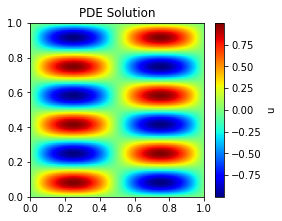

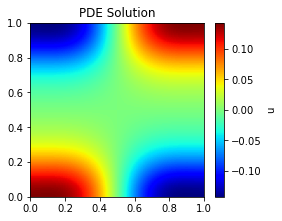

In [2]:
# PDE: u_t = alpha u_xx
alpha = 2.0
Lx = 1.0
Ly = 1.0
dx = 0.01
dy = 0.01
dt = 0.0001
t_end = 0.01  # Try varying this

# Initial condition: sin(3 pi x)
#u0 = lambda x: np.sin(3 * np.pi * x) + 1
#u0 = lambda x: x**2
#u0 = lambda x : np.where(np.sin(100*x) > 0.0, 1.0, 0.0)
#u0 = lambda x: np.where(np.abs(x) < .1, 100.0, 0.0)

N = 100
A = 1#np.random.randint(0,N)
j = 2#np.random.rand(0,N)
k = 6#np.random.rand(0,N)
def u0(x, y):
    return A * np.sin(j * np.pi * x) * np.sin(k * np.pi * y)


def u_exact(x, y, t):
    return A * np.sin(j * np.pi * x) * np.sin(k * np.pi * y) * np.exp(-((k * np.pi)**2 + (j * np.pi)**2) * t)



T, U = solve_heat2d(u0, alpha, dx, dy, t_end, Lx, Ly)

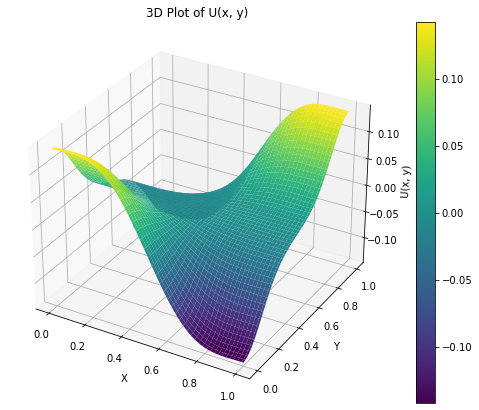

In [3]:
Nx = int(Lx / dx)
Ny = int(Ly / dy)
x = np.linspace(0, Lx, Nx)  # x values from 0 to Lx
y = np.linspace(0, Ly, Ny)  # y values from 0 to Ly
X, Y = np.meshgrid(x, y) 

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, U, cmap='viridis', edgecolor='none')
fig.colorbar(surf)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('U(x, y)')
ax.set_title('3D Plot of U(x, y)')


plt.show()

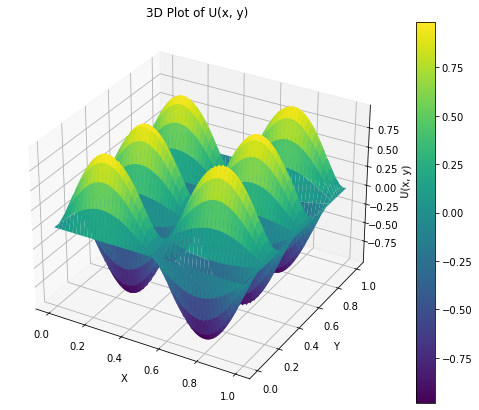

In [9]:
u_e = lambda x,y: u_exact(x, y, t_end)
V = u_e(X,Y)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, U0, cmap='viridis', edgecolor='none')
fig.colorbar(surf)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('U(x, y)')
ax.set_title('3D Plot of U(x, y)')


plt.show()

In [9]:
V.ndim

1

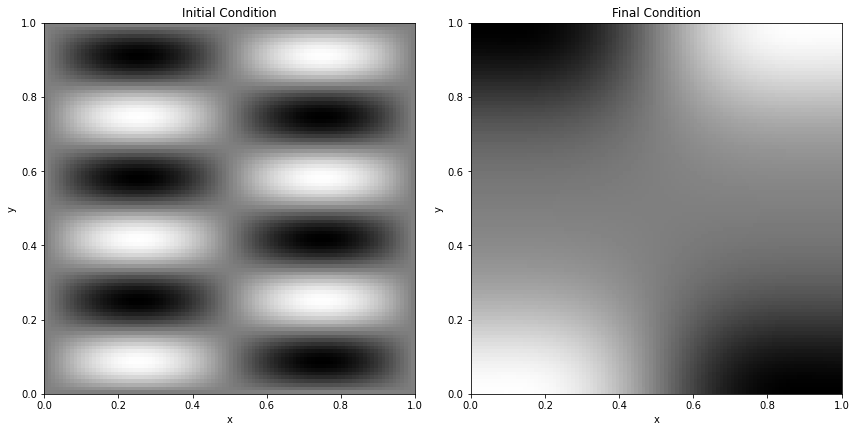

In [13]:
#Convert to image data 
U0 = u0(X,Y)
U0_normalized = (U0 - np.min(U0)) / (np.max(U0) - np.min(U0))
U0_scaled = (U0_normalized * 255).astype(np.uint8)

U_normalized = (U - np.min(U)) / (np.max(U) - np.min(U))
U_scaled = (U_normalized * 255).astype(np.uint8)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot the initial condition
axs[0].imshow(U0_scaled, cmap='gray', origin='lower', extent=(0, Lx, 0, Ly))
axs[0].set_title('Initial Condition')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')

# Plot the final condition
axs[1].imshow(U_scaled, cmap='gray', origin='lower', extent=(0, Lx, 0, Ly))
axs[1].set_title('Final Condition')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')


# Show the plot
plt.tight_layout()
plt.show()